## 1. Предобработка корпуса

* проводим лемматизацию и удаляем стоп-слова;
* приводем все леммы к нижнему регистру;
* добавляем частеречные теги.

Для предобработки мы будем использовать [*UDPipe*](https://ufal.mff.cuni.cz/udpipe)

In [1]:
pip install wget

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9711 sha256=5577625da988fd98987702518491c5e2ebc695aac665a70883db15da5941b0ec
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\40\b3\0f\a40dbd1c6861731779f62cc4babcb234387e11d697df70ee97
Successfully built wget
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import wget
import sys

udpipe_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'

modelfile = wget.download(udpipe_url)
print('ok')

ok


Функция для предобработки текста

In [5]:
def process(pipeline, text='Строка', keep_pos=True, keep_punct=False):
    entities = {'PROPN'}
    named = False
    memory = []
    mem_case = None
    mem_number = None
    tagged_propn = []

    # обрабатываем текст, получаем результат в формате conllu:
    processed = pipeline.process(text)

    # пропускаем строки со служебной информацией:
    content = [l for l in processed.split('\n') if not l.startswith('#')]

    # извлекаем из обработанного текста леммы, тэги и морфологические характеристики
    tagged = [w.split('\t') for w in content if w]

    for t in tagged:
        if len(t) != 10:
            continue
        (word_id, token, lemma, pos, xpos, feats, head, deprel, deps, misc) = t
        if not lemma or not token:
            continue
        if pos in entities:
            if '|' not in feats:
                tagged_propn.append('%s_%s' % (lemma, pos))
                continue
            morph = {el.split('=')[0]: el.split('=')[1] for el in feats.split('|')}
            if 'Case' not in morph or 'Number' not in morph:
                tagged_propn.append('%s_%s' % (lemma, pos))
                continue
            if not named:
                named = True
                mem_case = morph['Case']
                mem_number = morph['Number']
            if morph['Case'] == mem_case and morph['Number'] == mem_number:
                memory.append(lemma)
                if 'SpacesAfter=\\n' in misc or 'SpacesAfter=\\s\\n' in misc:
                    named = False
                    past_lemma = '::'.join(memory)
                    memory = []
                    tagged_propn.append(past_lemma + '_PROPN ')
            else:
                named = False
                past_lemma = '::'.join(memory)
                memory = []
                tagged_propn.append(past_lemma + '_PROPN ')
                tagged_propn.append('%s_%s' % (lemma, pos))
        else:
            if not named:
                if pos == 'NUM' and token.isdigit():  # Заменяем числа на xxxxx той же длины
                    continue
                tagged_propn.append('%s_%s' % (lemma, pos))
            else:
                named = False
                past_lemma = '::'.join(memory)
                memory = []
                tagged_propn.append(past_lemma + '_PROPN ')
                tagged_propn.append('%s_%s' % (lemma, pos))

    if not keep_punct:
        tagged_propn = [word for word in tagged_propn if word.split('_')[1] != 'PUNCT']
    if not keep_pos:
        tagged_propn = [word.split('_')[0] for word in tagged_propn]
    return tagged_propn

print('ok')


ok


In [6]:
pip install ufal.udpipe

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from ufal.udpipe import Model, Pipeline
import os
import re

def tag_ud(text='Текст нужно передать функции в виде строки!', modelfile='udpipe_syntagrus.model'):
    cnt = 0
    udpipe_model_url = 'https://rusvectores.org/static/models/udpipe_syntagrus.model'
    udpipe_filename = udpipe_model_url.split('/')[-1]

    if not os.path.isfile(modelfile):
        print('UDPipe model not found. Downloading...', file=sys.stderr)
        wget.download(udpipe_model_url)

    print('\nLoading the model...', file=sys.stderr)
    model = Model.load(modelfile)
    process_pipeline = Pipeline(model, 'tokenize', Pipeline.DEFAULT, Pipeline.DEFAULT, 'conllu')

    print('Processing input...', file=sys.stderr)
    lines = text.split('\n')
    tagged = []
    for line in lines:
        # line = unify_sym(line.strip()) # здесь могла бы быть ваша функция очистки текста
        output = process(process_pipeline, text=line)
        tagged_line = ' '.join(output)
        tagged.append(tagged_line)
        cnt += 1
        if cnt%1000 == 0:
            print(cnt)
    return '\n'.join(tagged)

Приступаем непосредственно к предобработке нашего корпуса.

In [8]:
text = open(r'combined1.txt', 'r', encoding='utf-8').read()
processed_text = tag_ud(text=text, modelfile=modelfile)
print(processed_text[:350])
with open('combined1.txt', 'w', encoding='utf-8') as out:
    out.write(processed_text)


Loading the model...
Processing input...


1000
2000
3000
4000
5000
6000
7000
8000

d_X \poem_corpus_1\_NOUN poem_corpus_filtered_1.txt_X
﻿_NOUN ночь_PROPN  Посвещаться_VERB Макс::павлов_PROPN  ночь_PROPN холодный_ADJ воздух_NOUN темнота_NOUN и_CCONJ лишь_PART луна_NOUN так_ADV высокий_ADJ и_CCONJ ты_PRON идти_VERB и_PART ты_PRON один_ADJ и_CCONJ думать_VERB что_PRON не_PART нужный_ADJ и_CCONJ словно_PART сон_NOUN стук_NOUN каблу


In [10]:
pip install gensim

  Obtaining dependency information for gensim from https://files.pythonhosted.org/packages/f5/57/f2e6568dbf464a4b270954e5fa3dee4a4054d163a41c0e7bf0a34eb40f0f/gensim-4.3.3-cp311-cp311-win_amd64.whl.metadata
  Using cached gensim-4.3.3-cp311-cp311-win_amd64.whl.metadata (8.2 kB)
Using cached gensim-4.3.3-cp311-cp311-win_amd64.whl (24.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import sys
import gensim, logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

Одна строка - одно предложение

In [12]:
f = 'combined1.txt'
data = gensim.models.word2vec.LineSentence(f)

2. Приступаем к обучению моделей

2.1 CBOW

Инициализируем модель. Параметры в скобочках:
* data - данные,
* size - размер вектора,
* window - размер окна наблюдения,
* min_count - мин. частотность слова в корпусе, которое мы берем,
* sg - используемый алгоритм обучение (0 - CBOW, 1 - Skip-gram))

In [13]:
model_CBOW = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=0)

2025-04-08 19:46:31,490 : INFO : collecting all words and their counts
2025-04-08 19:46:31,500 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-04-08 19:46:31,705 : INFO : collected 93517 word types from a corpus of 931484 raw words and 7980 sentences
2025-04-08 19:46:31,705 : INFO : Creating a fresh vocabulary
2025-04-08 19:46:31,777 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 31879 unique words (34.09% of original 93517, drops 61638)', 'datetime': '2025-04-08T19:46:31.777329', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2025-04-08 19:46:31,778 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 869846 word corpus (93.38% of original 931484, drops 61638)', 'datetime': '2025-04-08T19:46:31.778205', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:

Сколько слов в модели?

In [15]:
print(len(model_CBOW.wv.key_to_index))


31879


Сохраняем модель

In [16]:
model_CBOW.save('cbow_poem.model')

2025-04-08 19:48:04,910 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'cbow_poem.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-04-08T19:48:04.910785', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-04-08 19:48:04,910 : INFO : storing np array 'vectors' to cbow_poem.model.wv.vectors.npy
2025-04-08 19:48:04,999 : INFO : storing np array 'syn1neg' to cbow_poem.model.syn1neg.npy
2025-04-08 19:48:05,332 : INFO : not storing attribute cum_table
2025-04-08 19:48:05,351 : INFO : saved cbow_poem.model


Загружаем сохраненную модель

In [17]:
from gensim.models import Word2Vec
cbow = Word2Vec.load('cbow_poem.model')

2025-04-08 19:48:52,718 : INFO : loading Word2Vec object from cbow_poem.model
2025-04-08 19:48:52,740 : INFO : loading wv recursively from cbow_poem.model.wv.* with mmap=None
2025-04-08 19:48:52,740 : INFO : loading vectors from cbow_poem.model.wv.vectors.npy with mmap=None
2025-04-08 19:48:52,775 : INFO : loading syn1neg from cbow_poem.model.syn1neg.npy with mmap=None
2025-04-08 19:48:52,809 : INFO : setting ignored attribute cum_table to None
2025-04-08 19:48:52,941 : INFO : Word2Vec lifecycle event {'fname': 'cbow_poem.model', 'datetime': '2025-04-08T19:48:52.941607', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


Косинусное сходство

In [21]:
print(list(cbow.wv.key_to_index.keys())[:20])

['и_CCONJ', 'в_ADP', 'я_PRON', 'не_PART', 'ты_PRON', 'на_ADP', 'с_ADP', 'он_PRON', 'мы_PRON', 'быть_AUX', 'а_CCONJ', 'что_PRON', 'как_SCONJ', 'но_CCONJ', 'она_PRON', 'мой_DET', 'что_SCONJ', 'они_PRON', 'к_ADP', 'весь_DET']


In [18]:
cbow.wv.similarity("думать_VERB", "спать_VERB")

0.68262243

In [19]:
cbow.wv.similarity("один_ADJ", "нежный_ADJ")

0.49492192

In [20]:
cbow.wv.similarity("луна_NOUN", "темнота_NOUN")

0.9628244

In [22]:
cbow.wv.similarity("высокий_ADJ", "один_ADJ")  

0.7772646

In [23]:
for t in cbow.wv.most_similar(positive=[u'луна_NOUN'], topn=20):
    print (t[0], t[1])

море_NOUN 0.9788749814033508
крыло_NOUN 0.9726149439811707
берег_NOUN 0.9725184440612793
ярко_ADJ 0.9686892628669739
облако_NOUN 0.967681348323822
даль_NOUN 0.9632667899131775
темнота_NOUN 0.9628243446350098
поднебесье_NOUN 0.9603700637817383
сад_NOUN 0.9597998857498169
поле_NOUN 0.9592123031616211
тень_NOUN 0.9541199803352356
стекло_NOUN 0.9531248807907104
туман_NOUN 0.9529078602790833
далеко_NOUN 0.9519210457801819
вода_NOUN 0.9518816471099854
лететь_VERB 0.9512035846710205
зеркало_NOUN 0.9509040713310242
закат_NOUN 0.9502038955688477
заря_NOUN 0.9500781893730164
дерево_NOUN 0.9499637484550476


Евклидово расстояние

In [25]:
import numpy as np

euclid1 = np.linalg.norm(cbow.wv['симптом_NOUN'] - cbow.wv['луна_NOUN'])
euclid2 = np.linalg.norm(cbow.wv['симптом_NOUN'] - cbow.wv['дерево_NOUN'])
print(euclid1, euclid2)

5.0879893 4.32416


## 2.2 Skip-Gram

In [26]:
model_sg = gensim.models.Word2Vec(data, vector_size=500, window=5, min_count=2, sg=1)

2025-04-08 20:02:27,832 : INFO : collecting all words and their counts
2025-04-08 20:02:27,833 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-04-08 20:02:28,073 : INFO : collected 93517 word types from a corpus of 931484 raw words and 7980 sentences
2025-04-08 20:02:28,073 : INFO : Creating a fresh vocabulary
2025-04-08 20:02:28,148 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 31879 unique words (34.09% of original 93517, drops 61638)', 'datetime': '2025-04-08T20:02:28.148074', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'prepare_vocab'}
2025-04-08 20:02:28,149 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 leaves 869846 word corpus (93.38% of original 931484, drops 61638)', 'datetime': '2025-04-08T20:02:28.149075', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:

In [27]:
model_sg.save('skip-gram_poem.model')

2025-04-08 20:02:59,425 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'skip-gram_poem.model', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-04-08T20:02:59.425325', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-04-08 20:02:59,425 : INFO : storing np array 'vectors' to skip-gram_poem.model.wv.vectors.npy
2025-04-08 20:02:59,471 : INFO : storing np array 'syn1neg' to skip-gram_poem.model.syn1neg.npy
2025-04-08 20:02:59,515 : INFO : not storing attribute cum_table
2025-04-08 20:02:59,530 : INFO : saved skip-gram_poem.model


In [28]:
from gensim.models import Word2Vec
sg = Word2Vec.load('skip-gram_poem.model')

2025-04-08 20:03:15,056 : INFO : loading Word2Vec object from skip-gram_poem.model
2025-04-08 20:03:15,078 : INFO : loading wv recursively from skip-gram_poem.model.wv.* with mmap=None
2025-04-08 20:03:15,079 : INFO : loading vectors from skip-gram_poem.model.wv.vectors.npy with mmap=None
2025-04-08 20:03:15,094 : INFO : loading syn1neg from skip-gram_poem.model.syn1neg.npy with mmap=None
2025-04-08 20:03:15,132 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:03:15,262 : INFO : Word2Vec lifecycle event {'fname': 'skip-gram_poem.model', 'datetime': '2025-04-08T20:03:15.262005', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


In [29]:
for t in sg.wv.most_similar(positive=[u'луна_NOUN'], topn=20):
    print (t[0], t[1])

луна_PROPN 0.9144477248191833
оконце_NOUN 0.8732005953788757
лучик_NOUN 0.8690127730369568
бледный_ADJ 0.8689231276512146
блик_NOUN 0.8686509132385254
фонарь_NOUN 0.8637018799781799
обрыв_NOUN 0.8595805168151855
зеленый_ADJ 0.8592976927757263
солнышко_ADV 0.8591216802597046
вышина_NOUN 0.8587926626205444
венок_NOUN 0.8582791686058044
лебедь_NOUN 0.8574233055114746
пляж_NOUN 0.8572579026222229
покрывало_NOUN 0.856406569480896
вуаль_NOUN 0.8551287651062012
звезда_PROPN 0.8551228046417236
засиять_VERB 0.8550261855125427
шептаться_VERB 0.8548299074172974
береза_NOUN 0.8546939492225647
звездочка_NOUN 0.8545122146606445


In [30]:
sg.wv.similarity("думать_VERB", "спать_VERB")

0.586565

In [31]:
sg.wv.similarity("один_ADJ", "нежный_ADJ")

0.44134793

In [32]:
sg.wv.similarity("луна_NOUN", "темнота_NOUN")

0.78752184

In [33]:
sg.wv.similarity("высокий_ADJ", "один_ADJ")

0.5902306

In [34]:
euclid3 = np.linalg.norm(sg.wv['симптом_NOUN'] - sg.wv['луна_NOUN'])
euclid4 = np.linalg.norm(sg.wv['симптом_NOUN'] - sg.wv['дерево_NOUN'])
print(euclid3, euclid4)

2.1860309 2.012439


## Коллокаты

In [35]:
import re

for t in sg.wv.most_similar(positive=[u'луна_NOUN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

оконце_NOUN 0.8732005953788757
лучик_NOUN 0.8690127730369568
бледный_ADJ 0.8689231276512146
блик_NOUN 0.8686509132385254
фонарь_NOUN 0.8637018799781799
обрыв_NOUN 0.8595805168151855
зеленый_ADJ 0.8592976927757263
вышина_NOUN 0.8587926626205444


In [36]:
import re

for t in cbow.wv.most_similar(positive=[u'луна_NOUN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

море_NOUN 0.9788749814033508
крыло_NOUN 0.9726149439811707
берег_NOUN 0.9725184440612793
ярко_ADJ 0.9686892628669739
облако_NOUN 0.967681348323822
даль_NOUN 0.9632667899131775
темнота_NOUN 0.9628243446350098
поднебесье_NOUN 0.9603700637817383
сад_NOUN 0.9597998857498169
поле_NOUN 0.9592123031616211


In [38]:
pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/d7/68/0d03098b3feb786cbd494df0aac15b571effda7f7cbdec267e8a8d398c16/matplotlib-3.10.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/a8/7e/cd93cab453720a5d6cb75588cc17dcdc08fc3484b9de98b885924ff61900/contourpy-1.3.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/13/4c/de2612ea2216eb45cfc8eb91a8501615dd87716feaf5f8fb65cbca576289/fonttools-4.57.0-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/104.6 kB ? eta -:--:--
     ----------- --------------------------- 30.7/104.6 kB 1.4 MB/s 


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
pip install pandas

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/ed/8c/87ddf1fcb55d11f9f847e3c69bb1c6f8e46e2f40ab1a2d2abadb2401b007/pandas-2.2.3-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for pytz>=2020.1 from https://files.pythonhosted.org/packages/81/c4/34e93fe5f5429d7570ec1fa436f1986fb1f00c3e0f43a589fe2bbcd22c3f/pytz-2025.2-py2.py3-none-any.whl.metadata
  Obtaining dependency information for tzdata>=2022.7 from https://files.pythonhosted.org/packages/5c/23/c7abc0ca0a1526a0774eca151daeb8de62ec457e77262b66b359c3c7679e/tzdata-2025.2-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.6 MB 991.0 kB/s eta 0:00:12
   ---------------------------------------- 0.1/11.6 MB 1.4 MB/s eta 0:00:09
    --------------------------------------- 0.3/11.6 MB 2.2 MB/s eta 0:00:06
   - -------------------------------------- 0.5/11.6 MB 3.0 MB/s eta 0:00:0


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/294.9 kB 871.5 kB/s eta 0:00:01
   -------------------------- ------------- 194.6/294.9 kB 1.3 MB/s eta 0:00:01
   ------------------------------ --------- 225.3/294.9 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/a1/a6/c5b78606743a1f28eae8f11973de6613a5ee87366796583fb74c67d54939/scikit_learn-1.6.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/91/29/df4b9b42f2be0b623cbd5e2140cafcaa2bef0759a00b7b70104dcfe2fb51/joblib-1.4.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB 1.3 MB/s eta 0:00:09
   


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2025-04-08 20:17:49,900 : INFO : loading Word2Vec object from skip-gram_poem.model
2025-04-08 20:17:49,910 : INFO : loading wv recursively from skip-gram_poem.model.wv.* with mmap=None
2025-04-08 20:17:49,910 : INFO : loading vectors from skip-gram_poem.model.wv.vectors.npy with mmap=None
2025-04-08 20:17:49,921 : INFO : loading syn1neg from skip-gram_poem.model.syn1neg.npy with mmap=None
2025-04-08 20:17:49,972 : INFO : setting ignored attribute cum_table to None
2025-04-08 20:17:50,105 : INFO : Word2Vec lifecycle event {'fname': 'skip-gram_poem.model', 'datetime': '2025-04-08T20:17:50.105100', 'gensim': '4.3.3', 'python': '3.11.6 (tags/v3.11.6:8b6ee5b, Oct  2 2023, 14:57:12) [MSC v.1935 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


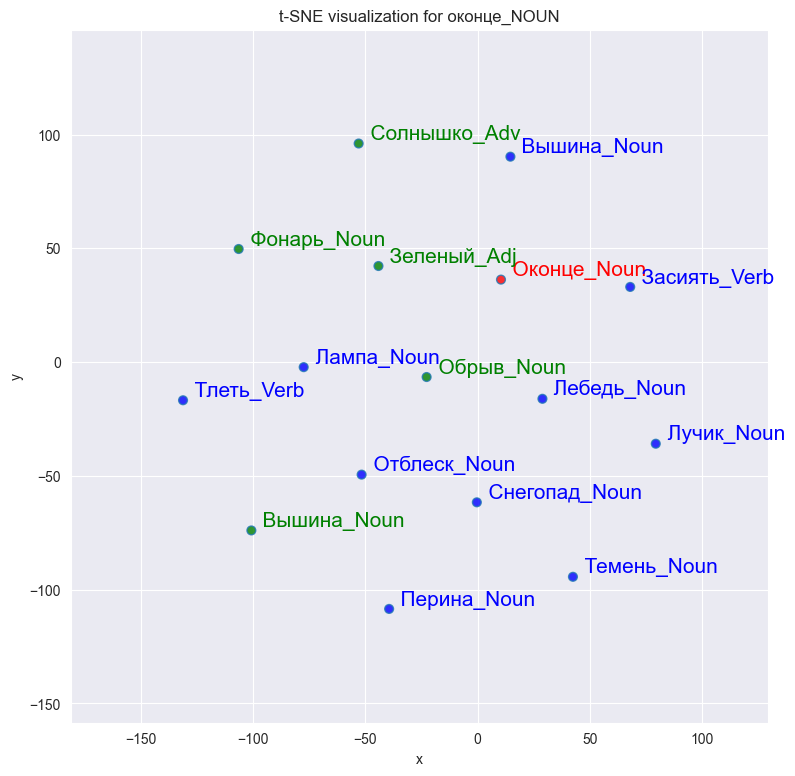

None


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("darkgrid")

# Загружаем модель Word2Vec
from gensim.models import Word2Vec
model = Word2Vec.load("skip-gram_poem.model")  # Укажи путь к своей модели

def tsnescatterplot(model, word, list_names):
    # Используем размерность вектора из модели
    arrays = np.empty((0, model.wv.vector_size), dtype='f')
    word_labels = [word]
    color_list = ['red']

    # Добавляем вектор целевого слова
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # Получаем семантические ассоциаты
    close_words = model.wv.most_similar([word])

    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)

    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    reduc = PCA(n_components=4).fit_transform(arrays)
    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)

    df = pd.DataFrame({'x': [x for x in Y[:, 0]],
                       'y': [y for y in Y[:, 1]],
                       'words': word_labels,
                       'color': color_list})

    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)

    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                  })

    for line in range(0, df.shape[0]):
        p1.text(df["x"][line],
                df['y'][line],
                '  ' + df["words"][line].title(),
                horizontalalignment='left',
                verticalalignment='bottom', size='medium',
                color=df['color'][line],
                weight='normal'
                ).set_size(15)

    plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
    plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)
    plt.title('t-SNE visualization for {}'.format(word))
    plt.show()

# Вызов функции с исправлением
print(tsnescatterplot(model, 'оконце_NOUN', [t[0] for t in model.wv.most_similar(positive=["луна_NOUN"], topn=10)][5:]))


## Оценка
Судя по оценкам (евклидово расстояние и косинусное расстояние) для подбора синонимов модель CBOW работает лучше, чем Skip-Gram.

Но Skip-Gram лучше определяет сходство между несинонимичными парами